<a href="https://colab.research.google.com/github/jlin219myseneca-art/Capstone_ModernConnectivity_Analysis_Investment/blob/main/Copy_of_tele.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This study addresses the following research questions:


*  Which census subdivisions in Ontario and Quebec exhibit the greatest concentration of unserved households with limited access to 50/10 Mbps broadband service?
* How can community characteristics, such as the presence of First Nations reserves or OLMCs, be combined with deployment efficiency proxies to establish an investment priority ranking?
*   To what extent do the prioritized investment locations align with Universal Broadband Fund eligibility criteria and Rogers’ digital inclusion objectives?








#Intro to Analysis + Data Cleaning Lead
Sections owned
1. Intro to analysis
2. Data cleaning
Responsibilities
Section 1: Intro to Analysis

Briefly restate:

Project purpose
Research questions (RQ1–RQ3)
Why broadband availability (50/10 Mbps) matters


Describe:

Geographic scope (Ontario & Quebec, CSD level)
Overall analytical approach (descriptive → inferential → ranking)



Section 2: Data Cleaning

Explain:

Data source (CRTC Excel file)
Why specific fields were selected


Document cleaning steps:

Filtering ON/QC
Handling multiple Speeds rows
Selecting 50/10/Any
Choosing household denominator (UsualResidentDwellings)
Creating derived variables:

ServedHH_50/10
UnservedHH_50/10
UnservedRate_50/10




Mention data limitations (availability ≠ adoption)

Deliverables

Written Sections 1 & 2
Variable definitions table (can go in appendix)

In [ ]:
!pip install pandasql  # 加這行！

import pandas as pd
import pandasql as psql



  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=e837d8bafce07cb9573bdeeaac50286a1a4958e4aaf0df96dbc89fb16479d925
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
# Load the correct sheet "c-t9", skipping the first 4 rows
df = pd.read_excel('/content/tele.xlsx', sheet_name='C-T9', header=4)

print("Number of columns:", len(df.columns))
print("Column names:", df.columns.tolist())
print(df.head())

Number of columns: 16
Column names: ['ProvinceID', 'Province/Territoire / Province/territory', 'ID de la subdivision de recensement / Census Subdivision ID', 'Nom de la subdivision de recensement / Census Subdivision Name', 'Centre de population / Population Centre', 'Secteurs des réserves des Premières Nations / First Nations reserve areas', 'Vitesses / Speeds', 'Année / Year', 'Logements / Dwellings', 'Logements des résidents habituels / Usual Resident Dwellings', 'Logements des CLOSM / OLMC Dwellings', 'Logements des résidents habituels des CLOSM / OLMC Usual Resident Dwelling', 'Logements des CLOSM limitées / OLMC Dwellings Limited', 'Population', 'Population des CLOSM / OLMC Population', 'Population des CLOSM limitées / OLMC Population Limited']
   ProvinceID Province/Territoire / Province/territory  \
0          48                                       AB   
1          35                                       ON   
2          47                                       SK   
3      

In [ ]:
# Map bilingual names → clean English names
# rename to english
df.columns = [
    'ProvinceID',
    'Province_Territory',
    'Census_Subdivision_ID',
    'Census_Subdivision_Name',
    'Population_Centre',
    'First_Nations_Reserve_Areas',
    'Speeds',
    'Year',
    'Dwellings',
    'Usual_Resident_Dwellings',
    'OLMC_Dwellings',
    'OLMC_Usual_Resident_Dwellings',
    'OLMC_Dwellings_Limited',
    'Population',
    'OLMC_Population',
    'OLMC_Population_Limited'
]

# show all columns in a line
from IPython.display import display
pd.set_option('display.max_columns', None)

display(df.head())

,ProvinceID,Province_Territory,Census_Subdivision_ID,Census_Subdivision_Name,Population_Centre,First_Nations_Reserve_Areas,Speeds,Year,Dwellings,Usual_Resident_Dwellings,OLMC_Dwellings,OLMC_Usual_Resident_Dwellings,OLMC_Dwellings_Limited,Population,OLMC_Population,OLMC_Population_Limited
0,48,AB,4807001,Provost No. 52,Rural,False,AllMobile,2019,929.940000,824.940000,2.246094,1.835937,2.053571,2204.900000,5.000000,4.571429
1,35,ON,3526053,St. Catharines,Rural,False,150+,2018,188.520168,179.539745,1.821211,1.743595,1.821181,502.173179,4.823734,4.823734
2,47,SK,4711072,Allan,Rural,False,AllDemographics,2017,274.000000,253.000000,0.000000,0.000000,0.000000,644.000000,0.000000,0.000000
3,35,ON,3546024,Dysart et al,"Les petits centres de population, comptent une...",False,16+,2020,559.000000,549.000000,0.000000,0.000000,0.000000,1149.000000,0.000000,0.000000
4,46,MB,4603058,Thompson,Rural,False,5+,2016,355.550222,329.412767,3.840817,3.735583,3.156600,1024.446032,13.880176,10.459124


In [ ]:
# Check missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Check duplicate rows
print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())

# Check data types
print("\n=== Data Types ===")
print(df.dtypes)

=== Missing Values ===
ProvinceID                          0
Province_Territory                  9
Census_Subdivision_ID               0
Census_Subdivision_Name             0
Population_Centre                   0
First_Nations_Reserve_Areas         0
Speeds                              0
Year                                0
Dwellings                           0
Usual_Resident_Dwellings            0
OLMC_Dwellings                   3345
OLMC_Usual_Resident_Dwellings    3345
OLMC_Dwellings_Limited           3337
Population                          0
OLMC_Population                  3337
OLMC_Population_Limited             0
dtype: int64

=== Duplicate Rows ===
0

=== Data Types ===
ProvinceID                         int64
Province_Territory                object
Census_Subdivision_ID              int64
Census_Subdivision_Name           object
Population_Centre                 object
First_Nations_Reserve_Areas         bool
Speeds                            object
Year                   

In [ ]:
# Fix data types
df['ProvinceID'] = df['ProvinceID'].astype(str)
df['Census_Subdivision_ID'] = df['Census_Subdivision_ID'].astype(str)
df['Year'] = df['Year'].astype(int)
print(df.dtypes)

ProvinceID                        object
Province_Territory                object
Census_Subdivision_ID             object
Census_Subdivision_Name           object
Population_Centre                 object
First_Nations_Reserve_Areas         bool
Speeds                            object
Year                               int64
Dwellings                        float64
Usual_Resident_Dwellings         float64
OLMC_Dwellings                   float64
OLMC_Usual_Resident_Dwellings    float64
OLMC_Dwellings_Limited           float64
Population                       float64
OLMC_Population                  float64
OLMC_Population_Limited          float64
dtype: object


In [ ]:
# check rows with missing value
df_missing = df[df['OLMC_Dwellings'].isnull()]
print(df_missing[['Province_Territory', 'Population_Centre', 'Speeds']].value_counts())

Province_Territory  Population_Centre                                                                                                                  Speeds         
BC                  Rural                                                                                                                              1.5+               72
                                                                                                                                                       NR                 72
                                                                                                                                                       LTE                72
                                                                                                                                                       AllDemographics    72
                                                                                                                                             

In [ ]:
# From a business analytics perspective, dropping these rows is justified for the following reasons:
# Quantity: 3345 / 796033 = 0.42%, which is well below the generally accepted 5% threshold,
# meaning dropping them will have negligible impact on the analysis.
# Column nature: The missing values are all in OLMC (Official Language Minority Communities) related columns.
# These are specialized statistics for minority language communities,
# and not every region is expected to have data — making this a structural absence rather than a random error.

In [ ]:
import pandasql as psql

def sql(query):
    return psql.sqldf(query, {'tele': df})

# 1️⃣ Remove duplicate rows
df = sql("SELECT DISTINCT * FROM tele")

# 2️⃣ Handle missing values (drop rows where key columns are NULL)
df = sql("""
    SELECT * FROM tele
    WHERE ProvinceID IS NOT NULL
    AND Population IS NOT NULL
    AND Dwellings IS NOT NULL
    AND Year IS NOT NULL
""")

# 3️⃣ Filter specific data (e.g. Rural and ON & QC areas only)
df = sql("""
    SELECT * FROM tele
    WHERE Population_Centre = 'Rural'
    AND Province_Territory = "ON" OR Province_Territory = "QC"
""")

print("Row count after cleaning:", len(df))
display(df.head())

Row count after cleaning: 291318


,ProvinceID,Province_Territory,Census_Subdivision_ID,Census_Subdivision_Name,Population_Centre,First_Nations_Reserve_Areas,Speeds,Year,Dwellings,Usual_Resident_Dwellings,OLMC_Dwellings,OLMC_Usual_Resident_Dwellings,OLMC_Dwellings_Limited,Population,OLMC_Population,OLMC_Population_Limited
0,35,ON,3526053,St. Catharines,Rural,0,150+,2018,188.520168,179.539745,1.821211,1.743595,1.821181,502.173179,4.823734,4.823734
1,24,QC,2488065,Saint-Dominique-du-Rosaire,Rural,0,50/10/Any,2024,198.114458,186.622892,0.000000,0.000000,0.000000,418.367470,0.000000,0.000000
2,24,QC,2471075,Terrasse-Vaudreuil,"Les grands centres de population urbains, comp...",0,50/10/Any,2019,799.963333,780.546667,250.358876,243.816366,250.358644,1918.227778,598.210975,598.210973
3,24,QC,2407912,Lac-Alfred,Rural,0,AllMobile,2022,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,24,QC,2467015,La Prairie,"Les grands centres de population urbains, comp...",0,200+,2017,9545.341096,9303.065920,799.202904,781.441854,799.202267,23128.489395,1985.848918,1985.848920


In [ ]:
print("Unique values in 'Speeds' column:")
print(df['Speeds'].unique())

Unique values in 'Speeds' column:
['150+' '50/10/Any' 'AllMobile' '200+' 'LTE' '16+' '5+' '25+' '1.5+'
 'HSPA+' '10+' 'AllDemographics' '50/10/U' 'Gigabit' '50+' 'LTEA' '100+'
 'NR']


In [ ]:
# Define Category
def speed_category(s):
    s = str(s).strip()
    if s in ['50/10/Any','50/10/U','50+','100+','150+','200+','Gigabit']:
        return 'Meets_5010'
    elif s in ['25+','16+','10+']:
        return 'Near_5010'
    elif s in ['5+','1.5+']:
        return 'Below_Broadband'
    elif s in ['AllMobile','LTE','LTEA','NR','HSPA+']:
        return 'Mobile_Only'
    else:
        return 'Exclude'

In [ ]:
df['Speed_Category'] = df['Speeds'].apply(speed_category)

In [ ]:
#captures all ≥50/10 tiers
#avoids missing rows due to naming inconsistencies
#future‑proofs your analysis
served5010 = (
    df[df['Speed_Category']=='Meets_5010']
      .groupby(['ProvinceID','Census_Subdivision_ID'], as_index=False)
      .agg(ServedHH_5010=('Usual_Resident_Dwellings','max'))
)

near5010 = (
    df[df['Speed_Category']=='Near_5010']
      .groupby(['ProvinceID','Census_Subdivision_ID'], as_index=False)
      .agg(ServedHH_Near5010=('Usual_Resident_Dwellings','max'))
)

# Merge served5010 into df first
master = df.merge(served5010, on=['ProvinceID','Census_Subdivision_ID'], how='left')

# Then merge near5010 into the master DataFrame
master = master.merge(near5010, on=['ProvinceID','Census_Subdivision_ID'], how='left')

master['ServedHH_Near5010'] = master['ServedHH_Near5010'].fillna(0)
master['ServedHH_5010'] = master['ServedHH_5010'].fillna(0) # Fill NaNs for served households as well

master['NearServedHH'] = (master['ServedHH_Near5010'] - master['ServedHH_5010']).clip(lower=0)

In [ ]:
master.columns

Index(['ProvinceID', 'Province_Territory', 'Census_Subdivision_ID',
       'Census_Subdivision_Name', 'Population_Centre',
       'First_Nations_Reserve_Areas', 'Speeds', 'Year', 'Dwellings',
       'Usual_Resident_Dwellings', 'OLMC_Dwellings',
       'OLMC_Usual_Resident_Dwellings', 'OLMC_Dwellings_Limited', 'Population',
       'OLMC_Population', 'OLMC_Population_Limited', 'Speed_Category',
       'ServedHH_5010', 'ServedHH_Near5010', 'NearServedHH'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np

# df = the long table with the columns listed

KEY = ['ProvinceID', 'Census_Subdivision_ID']

# Helper to convert FN field to 0/1 robustly
def to_flag(x):
    if pd.isna(x):
        return 0
    return 1 if str(x).strip().upper() in ['TRUE', '1', 'YES', 'Y', 'T'] else 0

# Apply FN_flag to the master DataFrame which contains the 'First_Nations_Reserve_Areas' column
master['FN_flag'] = master['First_Nations_Reserve_Areas'].apply(to_flag).astype(int)

# Build one record per CSD from the current master DataFrame
master = (
    master.groupby(KEY, as_index=False)
            .agg(
                Province=('Province_Territory', lambda s: s.dropna().astype(str).mode().iloc[0] if len(s.dropna()) else np.nan),
                CSD_Name=('Census_Subdivision_Name', lambda s: s.dropna().astype(str).mode().iloc[0] if len(s.dropna()) else np.nan),
                PopCentre=('Population_Centre', lambda s: s.dropna().astype(str).mode().iloc[0] if len(s.dropna()) else np.nan),
                TotalHH=('Usual_Resident_Dwellings','max'),
                TotalDwellings=('Dwellings','max'),
                Population=('Population','max'),
                FN_flag=('FN_flag','max'),
                OLMC_HH=('OLMC_Usual_Resident_Dwellings','max'),
                OLMC_Pop=('OLMC_Population','max'),

                # These 3 are already engineered; take max to keep the value
                ServedHH_5010=('ServedHH_5010','max'),
                ServedHH_Near5010=('ServedHH_Near5010','max'),
                NearServedHH=('NearServedHH','max')
            ))

# Derived metrics (recompute to be safe/consistent)
master['ServedHH_5010'] = master['ServedHH_5010'].fillna(0)
master['UnservedHH_5010'] = (master['TotalHH'] - master['ServedHH_5010']).clip(lower=0)
master['UnservedRate_5010'] = np.where(master['TotalHH']>0, master['UnservedHH_5010']/master['TotalHH'], np.nan)

master['OLMC_Share'] = np.where(master['TotalHH']>0, master['OLMC_HH']/master['TotalHH'], 0)
master['OLMC_flag'] = (master['OLMC_Share'] >= 0.10).astype(int)  # adjustable threshold

master.head()

,ProvinceID,Census_Subdivision_ID,Province,CSD_Name,PopCentre,TotalHH,TotalDwellings,Population,FN_flag,OLMC_HH,OLMC_Pop,ServedHH_5010,ServedHH_Near5010,NearServedHH,UnservedHH_5010,UnservedRate_5010,OLMC_Share,OLMC_flag
0,24,2401023,QC,Les Îles-de-la-Madeleine,"Les petits centres de population, comptent une...",4480.0,5303.0,9982.0,0,21.577699,46.000000,4416.341251,4469.740408,53.399157,63.658749,0.014210,0.004816,0
1,24,2401042,QC,Grosse-Île,Rural,220.0,254.0,465.0,0,186.099140,403.000000,218.705882,218.705882,0.000000,1.294118,0.005882,0.845905,1
2,24,2402005,QC,Percé,Rural,1550.0,1880.0,3103.0,0,339.348174,687.500009,1532.962812,1542.327690,9.364878,17.037188,0.010992,0.218934,1
3,24,2402010,QC,Sainte-Thérèse-de-Gaspé,Rural,475.0,509.0,1015.0,0,2.096248,5.000000,471.181818,475.000000,3.818182,3.818182,0.008038,0.004413,0
4,24,2402015,QC,Grande-Rivière,"Les petits centres de population, comptent une...",945.0,990.0,2054.0,0,16.955994,33.606061,941.515177,943.964539,2.449362,3.484823,0.003688,0.017943,0


In [ ]:
# Save cleaned dataset
master.to_csv('tele_cleaned.csv', index=False)
print("✅ Saved as tele_cleaned.csv")

✅ Saved as tele_cleaned.csv


### merge tab 8 - PoP distance table

In [ ]:
# First check how many rows to skip
df_t8_raw = pd.read_excel('tele.xlsx', sheet_name='C-T8', header=None)
print(df_t8_raw.head(10))

                                                   0                        1  \
0                                            Table 8                      NaN   
1  Distance between First Nations Reserves and th...                      NaN   
2                                                NaN                      NaN   
3                                                NaN                      NaN   
4                      Census subdivision identifier  Census subdivision name   
5                                            3560091                Peawanuck   
6                                            3560078           Fort Severn 89   
7                                            4623058              Churchill 1   
8                                            4718824          Fond du Lac 227   
9                                            5945802            Bella Coola 1   

                         2                           3  \
0                      NaN                        

In [ ]:
# Load Table 8 (adjust header= based on what you see above)
df_t8 = pd.read_excel('tele.xlsx', sheet_name='C-T8', header=4)
print(df_t8.columns.tolist())
print(df_t8.head())

['Census subdivision identifier', 'Census subdivision name', 'Census subdivision type', 'Name of province/territory', 2018, 2019]
  Census subdivision identifier Census subdivision name  \
0                       3560091               Peawanuck   
1                       3560078          Fort Severn 89   
2                       4623058             Churchill 1   
3                       4718824         Fond du Lac 227   
4                       5945802           Bella Coola 1   

  Census subdivision type Name of province/territory    2018    2019  
0                     S-É                    Ontario  262.12  262.06  
1                     IRI                    Ontario  274.38  259.33  
2                     IRI                   Manitoba   248.5   248.5  
3                     IRI               Saskatchewan  189.15  189.15  
4                     IRI           British Columbia  180.61  180.61  


In [ ]:
df_t8.columns = [
    'Census_Subdivision_ID',
    'Census_Subdivision_Name',
    'Census_Subdivision_Type',
    'Province_Territory',
    'Distance_PoP_2018',
    'Distance_PoP_2019'
]

# Fix ID type to match Table 9
df_t8['Census_Subdivision_ID'] = df_t8['Census_Subdivision_ID'].astype(str)

print(df_t8.head())

  Census_Subdivision_ID Census_Subdivision_Name Census_Subdivision_Type  \
0               3560091               Peawanuck                     S-É   
1               3560078          Fort Severn 89                     IRI   
2               4623058             Churchill 1                     IRI   
3               4718824         Fond du Lac 227                     IRI   
4               5945802           Bella Coola 1                     IRI   

  Province_Territory Distance_PoP_2018 Distance_PoP_2019  
0            Ontario            262.12            262.06  
1            Ontario            274.38            259.33  
2           Manitoba             248.5             248.5  
3       Saskatchewan            189.15            189.15  
4   British Columbia            180.61            180.61  


MERGE 2 TABLES

In [ ]:
# popdist is your df_t8 from the PoP sheet
popdist = df_t8.copy()

# 1) Standardize key dtype to match master
# Decide one standard: easiest is string for both
master['Census_Subdivision_ID'] = master['Census_Subdivision_ID'].astype(str)
popdist['Census_Subdivision_ID'] = popdist['Census_Subdivision_ID'].astype(str)

# 2) Map Province_Territory text -> ProvinceID (only ON/QC needed)
prov_map = {
    'Ontario': 35,
    'Quebec': 24,
    'Québec': 24
}
popdist['ProvinceID'] = popdist['Province_Territory'].map(prov_map)

# 3) Keep only ON/QC rows in PoP (important filter)
popdist = popdist[popdist['ProvinceID'].isin([24, 35])].copy()

# Convert to Int64 to remove decimals and then to string for consistent merging
popdist['ProvinceID'] = popdist['ProvinceID'].astype('Int64').astype(str)

# 4) Create a single distance field (prefer 2019)
popdist['Distance_PoP'] = popdist['Distance_PoP_2019'].fillna(popdist['Distance_PoP_2018'])

# 5) Keep only merge fields
popdist = popdist[['ProvinceID','Census_Subdivision_ID','Distance_PoP_2018','Distance_PoP_2019','Distance_PoP']].copy()

popdist.head()

,ProvinceID,Census_Subdivision_ID,Distance_PoP_2018,Distance_PoP_2019,Distance_PoP
0,35,3560091,262.12,262.06,262.06
1,35,3560078,274.38,259.33,259.33
7,35,3560052,170.17,170.17,170.17
16,35,3560053,152.93,152.93,152.93
17,24,2499816,151.48,151.46,151.46


In [ ]:
dups = popdist.duplicated(['ProvinceID','Census_Subdivision_ID']).sum()
print("PoP duplicate keys:", dups)

PoP duplicate keys: 0


In [ ]:
#It effectively consolidates entries to a single row per unique subdivision,
#keeping the 'latest' or 'highest' distance value if there were multiple.
popdist = (popdist.groupby(['ProvinceID','Census_Subdivision_ID'], as_index=False)
                  .agg(Distance_PoP_2018=('Distance_PoP_2018','max'),
                       Distance_PoP_2019=('Distance_PoP_2019','max'),
                       Distance_PoP=('Distance_PoP','max')))

In [ ]:
df_merged = pd.merge(
    master,       # Table 9 (cleaned)
    popdist,    # Table 8
    on='Census_Subdivision_ID',
    how='left'  # keep all Table 9 rows
)

# Drop ProvinceID_y if it exists and rename ProvinceID_x
if 'ProvinceID_y' in df_merged.columns:
    df_merged = df_merged.drop(columns=['ProvinceID_y'])
if 'ProvinceID_x' in df_merged.columns:
    df_merged = df_merged.rename(columns={'ProvinceID_x': 'ProvinceID'})

print("✅ Merged shape:", df_merged.shape)
display(df_merged.head())

✅ Merged shape: (1869, 21)


,ProvinceID,Census_Subdivision_ID,Province,CSD_Name,PopCentre,TotalHH,TotalDwellings,Population,FN_flag,OLMC_HH,OLMC_Pop,ServedHH_5010,ServedHH_Near5010,NearServedHH,UnservedHH_5010,UnservedRate_5010,OLMC_Share,OLMC_flag,Distance_PoP_2018,Distance_PoP_2019,Distance_PoP
0,24,2401023,QC,Les Îles-de-la-Madeleine,"Les petits centres de population, comptent une...",4480.0,5303.0,9982.0,0,21.577699,46.000000,4416.341251,4469.740408,53.399157,63.658749,0.014210,0.004816,0,NaN,NaN,NaN
1,24,2401042,QC,Grosse-Île,Rural,220.0,254.0,465.0,0,186.099140,403.000000,218.705882,218.705882,0.000000,1.294118,0.005882,0.845905,1,NaN,NaN,NaN
2,24,2402005,QC,Percé,Rural,1550.0,1880.0,3103.0,0,339.348174,687.500009,1532.962812,1542.327690,9.364878,17.037188,0.010992,0.218934,1,NaN,NaN,NaN
3,24,2402010,QC,Sainte-Thérèse-de-Gaspé,Rural,475.0,509.0,1015.0,0,2.096248,5.000000,471.181818,475.000000,3.818182,3.818182,0.008038,0.004413,0,NaN,NaN,NaN
4,24,2402015,QC,Grande-Rivière,"Les petits centres de population, comptent une...",945.0,990.0,2054.0,0,16.955994,33.606061,941.515177,943.964539,2.449362,3.484823,0.003688,0.017943,0,NaN,NaN,NaN


In [ ]:
df_merged.to_csv('tele_merged.csv', index=False)
print("✅ Saved as tele_merged.csv")

✅ Saved as tele_merged.csv


# Descriptive Statistics

# ============================================================
###– Descriptive Analysis & RQ1 Responsibilities
#
### Objective:
Answer RQ1 by describing and visualizing the concentration of households without access to 50/10 Mbps broadband service across Ontario and Quebec census subdivisions (CSDs).

### Tasks:
1) Produce descriptive statistics for key variables:
    - TotalHH
    - UnservedHH_5010
    - UnservedRate_5010
    - NearServedHH
#
 2) Identify CSDs with the greatest broadband under-service:
    - Rank CSDs by UnservedHH_5010 (absolute concentration)
    - Rank CSDs by UnservedRate_5010 (relative concentration)
    - Report Top 20 CSDs for Ontario and Quebec separately
#
 3) Conduct threshold analysis to show concentration of need:
    - Count CSDs with ≥10% unserved
    - Count CSDs with ≥25% unserved
    - Count CSDs with ≥100 unserved households
    - Count CSDs with ≥500 unserved households
#
 4) Create clear visualizations:
    - Bar charts for top unserved CSDs
    - Scatter plot (TotalHH vs UnservedRate_5010,
      bubble size = UnservedHH_5010)
    - (Optional) Choropleth map by CSD
#
 5) Write brief interpretations explaining:
    - Distribution patterns (median vs upper tail)
    - Why broadband under-service is concentrated, not universal
#
### Notes:
#### - Use the finalized master / df_merged table only
#### - Do NOT modify data, scoring, or models
#### - Focus strictly on descriptive evidence and interpretation
# ============================================================

In [24]:
# Environment Restoration:
#To save raw excel data loading, here is a shortcut assumed Data Cleaning and Merging csv files ready
import pandas as pd
import numpy as np

# 1. Configuration: Replace these with your actual Raw GitHub URLs
GITHUB_URLS = {
    "merged": "https://raw.githubusercontent.com/jlin219myseneca-art/Capstone_ModernConnectivity_Analysis_Investment/main/tele_merged.csv",
    "cleaned": "https://raw.githubusercontent.com/jlin219myseneca-art/Capstone_ModernConnectivity_Analysis_Investment/main/tele_cleaned.csv",
    "fsa_mapping": "https://raw.githubusercontent.com/jlin219myseneca-art/Capstone_ModernConnectivity_Analysis_Investment/main/fsa_to_csd_lookup_ON_QC.csv"
}

def load_environment():
    try:
        # Load Main Dataframes
        df_merged = pd.read_csv(GITHUB_URLS["merged"])
        master = pd.read_csv(GITHUB_URLS["cleaned"])
        fsa_csd = pd.read_csv(GITHUB_URLS["fsa_mapping"])

        # 2. Standardization & Data Integrity
        # Ensure IDs are strings to prevent merge/scientific notation issues
        for df in [df_merged, master, fsa_csd]:
            if 'Census_Subdivision_ID' in df.columns:
                df['Census_Subdivision_ID'] = df['Census_Subdivision_ID'].astype(str).str.replace(r'\.0$', '', regex=True)

        # 3. Create RQ1 Analysis View
        # Filter for valid household counts and normalize ProvinceID
        rq1 = df_merged.copy()
        rq1 = rq1[rq1['TotalHH'] > 0].copy()
        rq1['ProvinceID'] = rq1['ProvinceID'].astype(int)

        # 4. Display Formatting (for tables)
        rq1['UnservedHH_5010_disp'] = rq1['UnservedHH_5010'].round(0)
        rq1['UnservedRate_5010_disp'] = (rq1['UnservedRate_5010'] * 100).round(2)

        print(f"✅ Environment Restored successfully.")
        print(f"📊 Loaded {len(rq1)} CSDs and FSA mapping with {len(fsa_csd)} rows.")

        return df_merged, master, fsa_csd, rq1

    except Exception as e:
        print(f"❌ Error loading data from GitHub: {e}")
        return None, None, None, None

# Execute the load
df_merged, master, fsa_csd, rq1 = load_environment()

✅ Environment Restored successfully.
📊 Loaded 1761 CSDs and FSA mapping with 934 rows.


### Task 1

In [25]:
# 1) Served <= Total
bad1 = (master['ServedHH_5010'] > master['TotalHH']).sum()
print("ServedHH_5010 > TotalHH rows:", bad1)

# 2) Unserved rate bounds
bad2 = (~master['UnservedRate_5010'].between(0,1)).sum()
print("UnservedRate outside [0,1] rows:", bad2)

# 3) NearServedHH should be >= 0 (it’s a gap)
bad3 = (master['NearServedHH'] < 0).sum()
print("NearServedHH < 0 rows:", bad3)

# Summary stats
print(master[['TotalHH','ServedHH_5010','UnservedHH_5010','UnservedRate_5010','NearServedHH']].describe().T)


ServedHH_5010 > TotalHH rows: 0
UnservedRate outside [0,1] rows: 108
NearServedHH < 0 rows: 0
                    count         mean           std  min    25%         50%  \
TotalHH            1869.0  2250.881220  20921.419108  0.0  178.0  464.000000   
ServedHH_5010      1869.0  2209.104004  20921.468477  0.0  155.0  436.695331   
UnservedHH_5010    1869.0    41.777216    125.412881  0.0    0.0    2.415094   
UnservedRate_5010  1761.0     0.106092      0.243131  0.0    0.0    0.007264   
NearServedHH       1869.0    25.515632     84.055775  0.0    0.0    0.000000   

                           75%            max  
TotalHH            1136.000000  815944.000000  
ServedHH_5010      1066.000000  815944.000000  
UnservedHH_5010      19.330739    2097.993102  
UnservedRate_5010     0.054422       1.000000  
NearServedHH          7.818182    1378.536364  


In [26]:
# How many CSDs exceed meaningful thresholds?
{
    "CSDs with ≥10% unserved": int((master['UnservedRate_5010'] >= 0.10).sum()),
    "CSDs with ≥25% unserved": int((master['UnservedRate_5010'] >= 0.25).sum()),
    "CSDs with ≥100 unserved HH": int((master['UnservedHH_5010'] >= 100).sum()),
    "CSDs with ≥500 unserved HH": int((master['UnservedHH_5010'] >= 500).sum()),
}

{'CSDs with ≥10% unserved': 341,
 'CSDs with ≥25% unserved': 218,
 'CSDs with ≥100 unserved HH': 192,
 'CSDs with ≥500 unserved HH': 30}

## Task 2 Identify CSDs with the greatest broadband under-service:
* Rank CSDs by UnservedHH_5010 (absolute concentration)
* Rank CSDs by UnservedRate_5010 (relative concentration)
* Report Top 20 CSDs for Ontario and Quebec separately

In [27]:
# Choose the correct CSD name column (adjust if needed)
name_col = 'CSD_Name' if 'CSD_Name' in df_merged.columns else 'Census_Subdivision_Name'
id_col   = 'Census_Subdivision_ID'

# Use only rows with meaningful household denominators
rq1 = df_merged.copy()
original_shape = rq1.shape[0]
rq1 = rq1[rq1['TotalHH'].notna() & (rq1['TotalHH'] > 0)].copy()

# ---- FINAL ProvinceID normalization (moved from original cell rBfELPcVieFv) ----
rq1['ProvinceID'] = (
    rq1['ProvinceID']
    .astype(str)
    .str.strip()
    .str.replace(r'\\.0$', '', regex=True) # Escaped backslash for regex
    .astype(int)
)

print(f"Original rows in rq1: {original_shape}")
print(f"Rows in rq1 after TotalHH filter: {rq1.shape[0]}")
print(f"Data type of rq1['ProvinceID']: {rq1['ProvinceID'].dtype}")
print(f"Unique values in rq1['ProvinceID']: {rq1['ProvinceID'].unique()}")
print("Descriptive statistics for TotalHH after filter:")
print(rq1['TotalHH'].describe())

# Optional: round display fields for tables (keep raw for calculations)
rq1['UnservedHH_5010_disp'] = rq1['UnservedHH_5010'].round(0)
rq1['UnservedRate_5010_disp'] = (rq1['UnservedRate_5010']*100).round(2)  # percent


Original rows in rq1: 1869
Rows in rq1 after TotalHH filter: 1761
Data type of rq1['ProvinceID']: int64
Unique values in rq1['ProvinceID']: [24 35]
Descriptive statistics for TotalHH after filter:
count      1761.000000
mean       2388.925043
std       21546.114079
min           1.000000
25%         215.000000
50%         505.000000
75%        1221.000000
max      815944.000000
Name: TotalHH, dtype: float64


###2.1 Rank CSDs by UnservedHH_5010 (absolute concentration) - This is the core of Request Question 1(RQ1):
Absolute concentration: most unserved households

In [28]:
#Create a new subset called rq1_conc (for concentration analysis)
rq1_conc = rq1[rq1['UnservedHH_5010'] >= 1].copy()


In [29]:
def top_abs(prov_id, n=20):
    return (
        rq1[rq1['ProvinceID'] == prov_id] # Removed str() conversion here
        .sort_values('UnservedHH_5010', ascending=False)
        .loc[:, ['ProvinceID', id_col, name_col, 'TotalHH',
                 'UnservedHH_5010', 'UnservedHH_5010_disp',
                 'UnservedRate_5010', 'UnservedRate_5010_disp']]
        .head(n)
    )

top_on_abs = top_abs(35, 20)
top_qc_abs = top_abs(24, 20)

print("Top 20 Ontario CSDs by Unserved Households (50/10):")
display(top_on_abs)

print("\nTop 20 Quebec CSDs by Unserved Households (50/10):")
display(top_qc_abs)

Top 20 Ontario CSDs by Unserved Households (50/10):


,ProvinceID,Census_Subdivision_ID,CSD_Name,TotalHH,UnservedHH_5010,UnservedHH_5010_disp,UnservedRate_5010,UnservedRate_5010_disp
1859,35,3560090,"Kenora, Unorganized",3272.0,2097.993102,2098.0,0.641196,64.12
1777,35,3558090,"Thunder Bay, Unorganized",2784.0,1250.770413,1251.0,0.449271,44.93
1663,35,3553005,Greater Sudbury / Grand Sudbury,13579.0,1246.167259,1246.0,0.091772,9.18
1432,35,3528052,Norfolk County,13209.0,1240.445739,1240.0,0.093909,9.39
1745,35,3557095,"Algoma, Unorganized, North Part",2773.0,995.501107,996.0,0.358998,35.90
1690,35,3554094,"Timiskaming, Unorganized, West Part",1396.0,912.480959,912.0,0.653640,65.36
1304,35,3506008,Ottawa,23230.0,865.426316,865.0,0.037255,3.73
1561,35,3546015,Minden Hills,3229.0,848.638463,849.0,0.262818,26.28
1662,35,3552093,"Sudbury, Unorganized, North Part",1367.0,751.700707,752.0,0.549891,54.99
1692,35,3556027,Timmins,3084.0,725.936543,726.0,0.235388,23.54



Top 20 Quebec CSDs by Unserved Households (50/10):


,ProvinceID,Census_Subdivision_ID,CSD_Name,TotalHH,UnservedHH_5010,UnservedHH_5010_disp,UnservedRate_5010,UnservedRate_5010_disp
1270,24,2499814,Chisasibi,772.0,772.000000,772.0,1.000000,100.00
1254,24,2499095,Kuujjuaq,709.0,709.000000,709.0,1.000000,100.00
653,24,2452095,Mandeville,1242.0,502.479026,502.0,0.404572,40.46
1264,24,2499802,Waswanipi,415.0,414.000000,414.0,0.997590,99.76
445,24,2438010,Bécancour,3877.0,381.139906,381.0,0.098308,9.83
691,24,2456005,Venise-en-Québec,806.0,366.444923,366.0,0.454646,45.46
1221,24,2498015,Côte-Nord-du-Golfe-du-Saint-Laurent,361.0,361.000000,361.0,1.000000,100.00
1247,24,2499060,Eeyou Istchee Baie-James,906.0,356.002593,356.0,0.392939,39.29
1261,24,2499130,Kangiqsujuaq,297.0,297.000000,297.0,1.000000,100.00
1218,24,2498010,Bonne-Espérance,282.0,282.000000,282.0,1.000000,100.00


### 2.2 Rank CSDs by UnservedHH_5010 (relative concentration)
Relative concentration: highest unserved rate (severity)

In [30]:
def top_rate(prov_id, n=20, min_hh=100):
    subset = rq1[(rq1['ProvinceID'] == prov_id) & (rq1['TotalHH'] >= min_hh)] # Removed str() conversion here
    return (
        subset
        .sort_values('UnservedRate_5010', ascending=False)
        .loc[:, ['ProvinceID', id_col, name_col, 'TotalHH',
                 'UnservedHH_5010', 'UnservedHH_5010_disp',
                 'UnservedRate_5010', 'UnservedRate_5010_disp']]
        .head(n)
    )

top_on_rate = top_rate(35, 20, min_hh=100)
top_qc_rate = top_rate(24, 20, min_hh=100)

print("Top 20 Ontario CSDs by Unserved Rate (50/10), TotalHH>=100:")
display(top_on_rate)

print("\nTop 20 Quebec CSDs by Unserved Rate (50/10), TotalHH>=100:")
display(top_qc_rate)

Top 20 Ontario CSDs by Unserved Rate (50/10), TotalHH>=100:


,ProvinceID,Census_Subdivision_ID,CSD_Name,TotalHH,UnservedHH_5010,UnservedHH_5010_disp,UnservedRate_5010,UnservedRate_5010_disp
1863,35,3560096,Kasabonika Lake,179.0,179.000000,179.0,1.000000,100.00
1824,35,3560050,Fort Albany (Part) 67,251.0,251.000000,251.0,1.000000,100.00
1827,35,3560053,Fort Hope 64,258.0,258.000000,258.0,1.000000,100.00
1763,35,3558062,Pic River 50,166.0,166.000000,166.0,1.000000,100.00
1755,35,3558034,Dorion,160.0,160.000000,160.0,1.000000,100.00
1817,35,3560024,Eagle Lake 27,101.0,101.000000,101.0,1.000000,100.00
1683,35,3554056,Matachewan,134.0,134.000000,134.0,1.000000,100.00
1849,35,3560079,Webequie,166.0,166.000000,166.0,1.000000,100.00
1835,35,3560061,Wabaseemoong,224.0,224.000000,224.0,1.000000,100.00
1832,35,3560058,English River 21,198.0,198.000000,198.0,1.000000,100.00



Top 20 Quebec CSDs by Unserved Rate (50/10), TotalHH>=100:


,ProvinceID,Census_Subdivision_ID,CSD_Name,TotalHH,UnservedHH_5010,UnservedHH_5010_disp,UnservedRate_5010,UnservedRate_5010_disp
1255,24,2499100,Tasiujaq,106.0,106.000000,106.0,1.000000,100.00
1270,24,2499814,Chisasibi,772.0,772.000000,772.0,1.000000,100.00
1254,24,2499095,Kuujjuaq,709.0,709.000000,709.0,1.000000,100.00
1253,24,2499090,Kangiqsualujjuaq,247.0,247.000000,247.0,1.000000,100.00
1258,24,2499115,Quaqtaq,144.0,144.000000,144.0,1.000000,100.00
1221,24,2498015,Côte-Nord-du-Golfe-du-Saint-Laurent,361.0,361.000000,361.0,1.000000,100.00
1220,24,2498014,Gros-Mécatina,204.0,204.000000,204.0,1.000000,100.00
1219,24,2498012,Saint-Augustin,198.0,198.000000,198.0,1.000000,100.00
1218,24,2498010,Bonne-Espérance,282.0,282.000000,282.0,1.000000,100.00
1257,24,2499110,Kangirsuk,170.0,170.000000,170.0,1.000000,100.00


### Task 3 Conduct threshold analysis to show concentration of need:
* Count CSDs with ≥10% unserved
* Count CSDs with ≥25% unserved
* Count CSDs with ≥100 unserved households
* Count CSDs with ≥500 unserved households

In [31]:
thresholds = {
    "CSDs with ≥10% unserved": int((rq1['UnservedRate_5010'] >= 0.10).sum()),
    "CSDs with ≥25% unserved": int((rq1['UnservedRate_5010'] >= 0.25).sum()),
    "CSDs with ≥100 unserved households": int((rq1['UnservedHH_5010'] >= 100).sum()),
    "CSDs with ≥500 unserved households": int((rq1['UnservedHH_5010'] >= 500).sum()),
}

thresholds_by_prov = (rq1.assign(
    ge10 = rq1['UnservedRate_5010'] >= 0.10,
    ge25 = rq1['UnservedRate_5010'] >= 0.25,
    ge100hh = rq1['UnservedHH_5010'] >= 100,
    ge500hh = rq1['UnservedHH_5010'] >= 500
).groupby('ProvinceID')[['ge10','ge25','ge100hh','ge500hh']].sum()
 .rename(columns={'ge10':'≥10%','ge25':'≥25%','ge100hh':'≥100HH','ge500hh':'≥500HH'})
)

print("Threshold counts (All ON+QC):")
display(pd.DataFrame.from_dict(thresholds, orient='index', columns=['Count']))

print("\nThreshold counts by province (ProvinceID 35=ON, 24=QC):")
display(thresholds_by_prov)

Threshold counts (All ON+QC):


,Count
CSDs with ≥10% unserved,341
CSDs with ≥25% unserved,218
CSDs with ≥100 unserved households,192
CSDs with ≥500 unserved households,30



Threshold counts by province (ProvinceID 35=ON, 24=QC):


,≥10%,≥25%,≥100HH,≥500HH
ProvinceID,,,,
24,113,65,36,3
35,228,153,156,27


In [32]:
# Remove de-minimis residuals for concentration metrics
rq1_conc = rq1[rq1['UnservedHH_5010'] >= 1].copy()

In [33]:
def concentration_share(prov_id=None, top_n=50):
    data = rq1_conc if prov_id is None else rq1_conc[rq1_conc['ProvinceID'] == int(prov_id)]

    total_unserved = data['UnservedHH_5010'].sum()
    if total_unserved <= 0:
        return np.nan

    top_unserved = (
        data.sort_values('UnservedHH_5010', ascending=False)
            .head(top_n)['UnservedHH_5010']
            .sum()
    )
    return float(top_unserved / total_unserved)


In [34]:
share_all_50 = concentration_share(None, 50)
share_on_50  = concentration_share(35, 50)
share_qc_50  = concentration_share(24, 50)

print(f"Share of ALL unserved households in Top 50 CSDs (ON+QC): {share_all_50:.1%}")
print(f"Share of ON unserved households in Top 50 ON CSDs: {share_on_50:.1%}")
print(f"Share of QC unserved households in Top 50 QC CSDs: {share_qc_50:.1%}")

Share of ALL unserved households in Top 50 CSDs (ON+QC): 41.4%
Share of ON unserved households in Top 50 ON CSDs: 51.4%
Share of QC unserved households in Top 50 QC CSDs: 58.2%


### Task 4 Visualziation

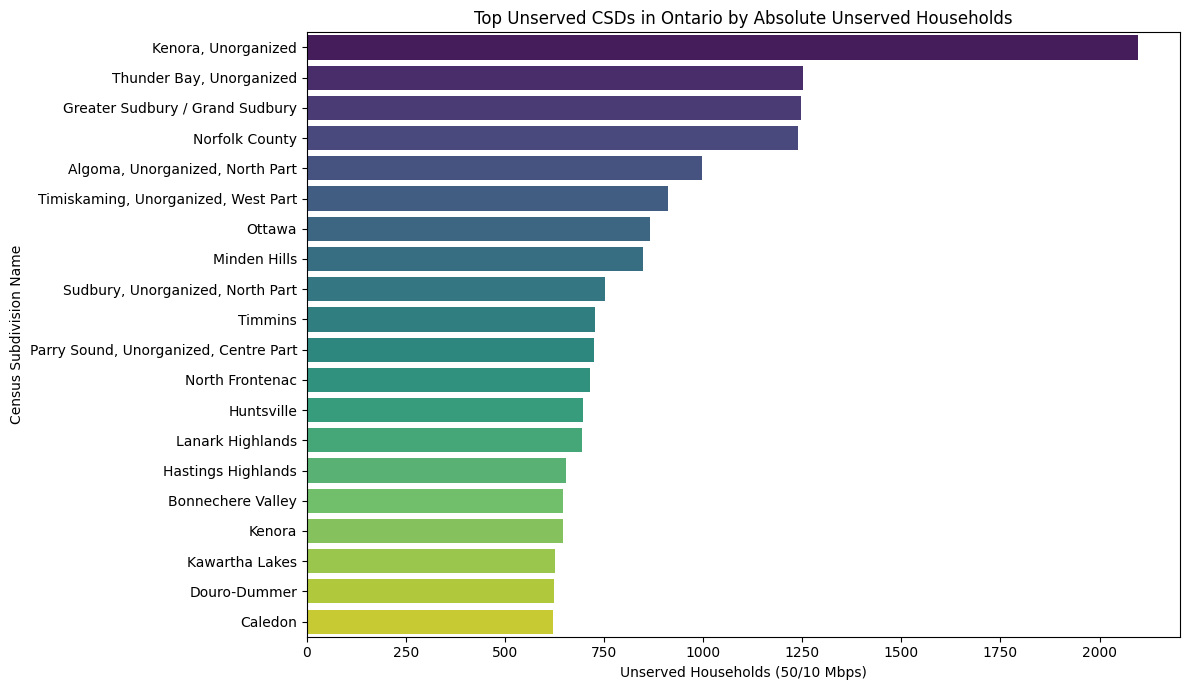

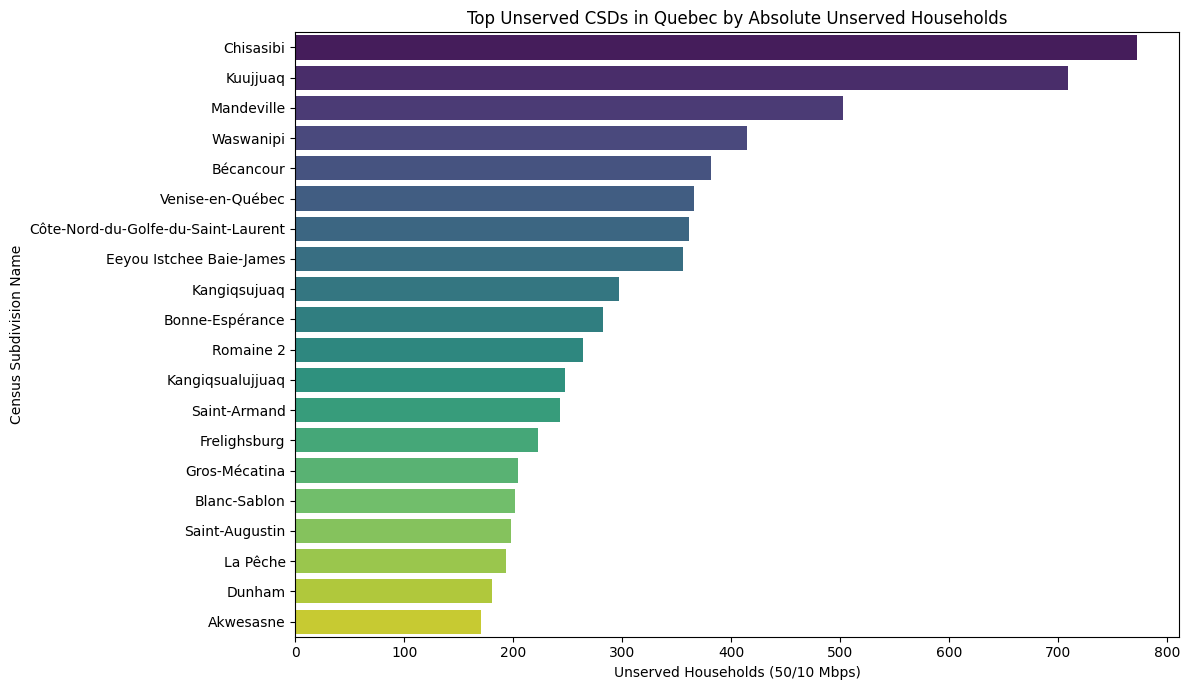

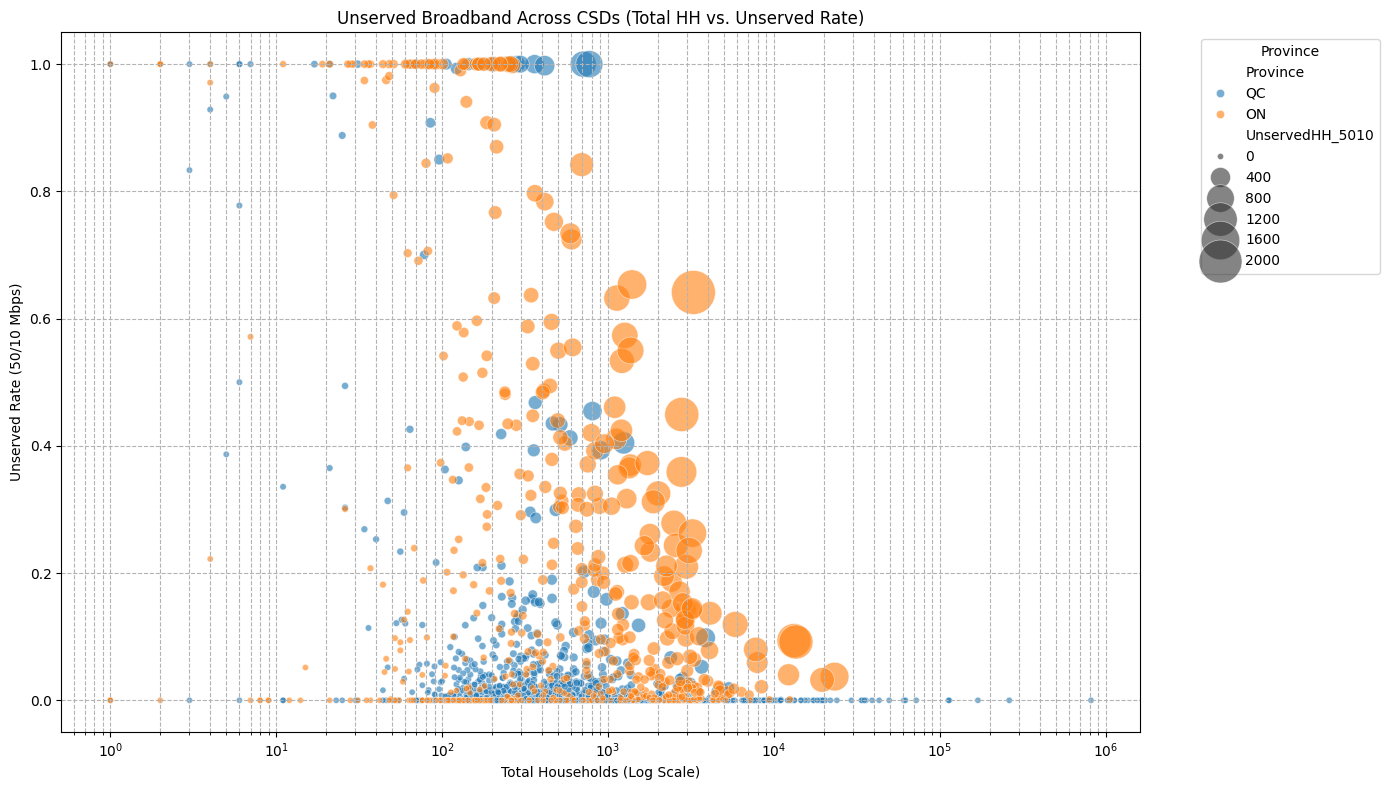

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_unserved_bar_chart(df, province_name, metric_col, title):
    plt.figure(figsize=(12, 7))
    sns.barplot(x=metric_col, y='CSD_Name', data=df, palette='viridis', hue='CSD_Name', legend=False)
    plt.xlabel('Unserved Households (50/10 Mbps)')
    plt.ylabel('Census Subdivision Name')
    plt.title(f'Top Unserved CSDs in {province_name} by {title}')
    plt.tight_layout()
    plt.show()

# Plot for Ontario
plot_top_unserved_bar_chart(
    top_on_abs,
    'Ontario',
    'UnservedHH_5010_disp',
    'Absolute Unserved Households'
)

# Plot for Quebec
plot_top_unserved_bar_chart(
    top_qc_abs,
    'Quebec',
    'UnservedHH_5010_disp',
    'Absolute Unserved Households'
)

# Create a scatter plot (TotalHH vs UnservedRate_5010, bubble size = UnservedHH_5010)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=rq1,
    x='TotalHH',
    y='UnservedRate_5010',
    size='UnservedHH_5010', # Bubble size proportional to UnservedHH_5010
    sizes=(20, 1000),      # Range of bubble sizes
    hue='Province',        # Differentiate provinces by color
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

print()

plt.xscale('log') # Use a log scale for TotalHH for better distribution visibility
plt.xlabel('Total Households (Log Scale)')
plt.ylabel('Unserved Rate (50/10 Mbps)')
plt.title('Unserved Broadband Across CSDs (Total HH vs. Unserved Rate)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Province', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Task5. Interpretation of Broadband Coverage Variables

The broadband coverage variables in this table represent **cumulative coverage extents**, not mutually exclusive household categories.

- **ServedHH_5010**  
  Estimated households with access to fixed broadband meeting or exceeding the 50/10 Mbps universal service objective.

- **ServedHH_Near5010**  
  Estimated households with access to fixed broadband below 50/10 Mbps but close to it (e.g., 10+, 16+, or 25 Mbps).  
  This value **includes** households already counted in ServedHH_5010.

- **NearServedHH**  
  Incremental upgrade opportunity, calculated as:  
  `ServedHH_Near5010 − ServedHH_5010`.

- **UnservedHH_5010**  
  Estimated households without access to 50/10 Mbps, calculated as:  
  `TotalHH − ServedHH_5010`.

- **UnservedRate_5010**  
  Share of households in the census subdivision that do not meet the 50/10 Mbps threshold.

###Ontario dominates absolute gaps; Quebec dominates extreme rates
Interpretation

Ontario’s challenge is scale (many households affected)
Quebec’s challenge is severity (very high rates in small communities)
This provincial contrast reinforces the need for dual criteria:

* scale and severity  

Because broadband availability is derived from spatial coverage modeling, household counts may be fractional. These values are retained for analytical precision and rounded only for presentation.

#Takeaway:

###Taken together, these variables show that while most census subdivisions exhibit near‑universal 50/10 Mbps coverage, broadband under‑service is unevenly distributed, with a small subset of communities accounting for a disproportionate share of unserved households.

# RQ 2 (Person 3)

In [36]:
import pandas as pd
import numpy as np

# Make a copy so original data stays unchanged
rq2 = df_merged.copy()

print(rq2.shape)
print(rq2.columns.tolist())

(1869, 21)
['ProvinceID', 'Census_Subdivision_ID', 'Province', 'CSD_Name', 'PopCentre', 'TotalHH', 'TotalDwellings', 'Population', 'FN_flag', 'OLMC_HH', 'OLMC_Pop', 'ServedHH_5010', 'ServedHH_Near5010', 'NearServedHH', 'UnservedHH_5010', 'UnservedRate_5010', 'OLMC_Share', 'OLMC_flag', 'Distance_PoP_2018', 'Distance_PoP_2019', 'Distance_PoP']


In [37]:
cols_needed = [
    'UnservedRate_5010',
    'UnservedHH_5010',
    'TotalHH',
    'FN_flag',
    'OLMC_flag',
    'Distance_PoP'
]

rq2 = rq2[cols_needed].copy()
print(rq2.head())

   UnservedRate_5010  UnservedHH_5010  TotalHH  FN_flag  OLMC_flag  \
0           0.014210        63.658749   4480.0        0          0   
1           0.005882         1.294118    220.0        0          1   
2           0.010992        17.037188   1550.0        0          1   
3           0.008038         3.818182    475.0        0          0   
4           0.003688         3.484823    945.0        0          0   

  Distance_PoP  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  


In [38]:
rq2 = df_merged.copy()

cols_needed = [
    'UnservedRate_5010',
    'UnservedHH_5010',
    'TotalHH',
    'FN_flag',
    'OLMC_flag',
    'Distance_PoP'
]

rq2 = rq2[cols_needed].copy()

print(rq2.head())

   UnservedRate_5010  UnservedHH_5010  TotalHH  FN_flag  OLMC_flag  \
0           0.014210        63.658749   4480.0        0          0   
1           0.005882         1.294118    220.0        0          1   
2           0.010992        17.037188   1550.0        0          1   
3           0.008038         3.818182    475.0        0          0   
4           0.003688         3.484823    945.0        0          0   

  Distance_PoP  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  


In [39]:
rq2 = rq2.dropna(subset=[
    'UnservedRate_5010',
    'FN_flag',
    'OLMC_flag',
    'Distance_PoP'
])

rq2 = rq2[rq2['TotalHH'] > 0].copy()

print("Final dataset size:", rq2.shape)
rq2.head()

Final dataset size: (162, 6)


,UnservedRate_5010,UnservedHH_5010,TotalHH,FN_flag,OLMC_flag,Distance_PoP
50,0.0,0.0,257.0,1,1,2.97
51,0.0,0.0,579.0,1,1,0.08
277,0.0,0.0,1019.0,1,0,Point of presence located within the reserve
456,0.0,0.0,97.0,1,0,0.73
621,0.0,0.0,138.0,1,0,0.51


In [40]:
from scipy.stats import ttest_ind

fn_0 = rq2[rq2['FN_flag'] == 0]['UnservedRate_5010']
fn_1 = rq2[rq2['FN_flag'] == 1]['UnservedRate_5010']

t_stat_fn, p_val_fn = ttest_ind(fn_0, fn_1, equal_var=False)

print("FN Test")
print("T-stat:", t_stat_fn)
print("P-value:", p_val_fn)

FN Test
T-stat: nan
P-value: nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [41]:
print("FN = 0 count:", len(fn_0))
print("FN = 1 count:", len(fn_1))

print("\nMean Unserved Rate by FN_flag:")
print(rq2.groupby('FN_flag')['UnservedRate_5010'].mean())

FN = 0 count: 0
FN = 1 count: 162

Mean Unserved Rate by FN_flag:
FN_flag
1    0.342303
Name: UnservedRate_5010, dtype: float64


A t-test was first attempted to compare unserved broadband rates between CSDs with and without First Nations presence. However, the test returned NaN values because the available sample after filtering was too small for a valid statistical comparison. For this reason, the analysis was interpreted using group counts and mean unserved rates instead.

In [42]:
from scipy.stats import ttest_ind

olmc_0 = rq2[rq2['OLMC_flag'] == 0]['UnservedRate_5010']
olmc_1 = rq2[rq2['OLMC_flag'] == 1]['UnservedRate_5010']

t_stat_olmc, p_val_olmc = ttest_ind(olmc_0, olmc_1, equal_var=False)

print("OLMC Test")
print("T-stat:", t_stat_olmc)
print("P-value:", p_val_olmc)

print("\nOLMC = 0 count:", len(olmc_0))
print("OLMC = 1 count:", len(olmc_1))

print("\nMean Unserved Rate by OLMC_flag:")
print(rq2.groupby('OLMC_flag')['UnservedRate_5010'].mean())

OLMC Test
T-stat: 1.6727876975296945
P-value: 0.10692979960747828

OLMC = 0 count: 143
OLMC = 1 count: 19

Mean Unserved Rate by OLMC_flag:
OLMC_flag
0    0.360537
1    0.205068
Name: UnservedRate_5010, dtype: float64


In [43]:
rq2['Distance_PoP'] = pd.to_numeric(rq2['Distance_PoP'], errors='coerce')

rq2_dist = rq2.dropna(subset=['Distance_PoP', 'UnservedRate_5010']).copy()

print("Distance analysis dataset size:", rq2_dist.shape)
print(rq2_dist[['Distance_PoP', 'UnservedRate_5010']].head())

Distance analysis dataset size: (91, 6)
     Distance_PoP  UnservedRate_5010
50           2.97                0.0
51           0.08                0.0
456          0.73                0.0
621          0.51                0.0
761         66.08                0.0


In [44]:
from scipy.stats import pearsonr

corr, p_val_corr = pearsonr(rq2_dist['Distance_PoP'], rq2_dist['UnservedRate_5010'])

print("Distance Correlation")
print("Correlation:", corr)
print("P-value:", p_val_corr)

Distance Correlation
Correlation: 0.31834962056862043
P-value: 0.00210283435011398


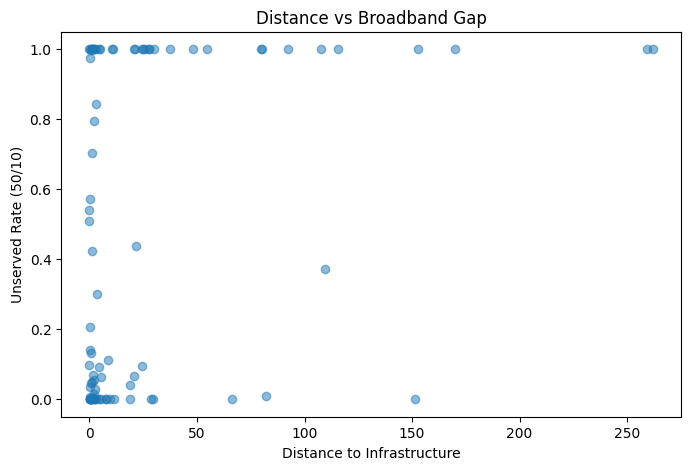

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(rq2_dist['Distance_PoP'], rq2_dist['UnservedRate_5010'], alpha=0.5)
plt.xlabel("Distance to Infrastructure")
plt.ylabel("Unserved Rate (50/10)")
plt.title("Distance vs Broadband Gap")
plt.show()

# Connectivity Priority Lookup — Phase 1 (Python / Colab)
Goal (what the Lookup does)
Allow a user to input a Canadian postal code and receive a plain‑English broadband summary for the corresponding area, based on your analysis.
Output should answer:

Where is this postal code (CSD, province)?
Is the area well served at 50/10?
Is it a high / medium / low priority area?
Is it likely eligible for UBF‑style funding?
What is the likely investment pathway (upgrade vs new build)?
What is the indicative ROI horizon (short / medium / long)?

This is a decision‑support tool, not a promise or forecast.

### Define utility rules:
1. Priority tier (example):

* HIGH: UnservedRate ≥ 25% OR UnservedHH ≥ 500

* MEDIUM: UnservedRate ≥ 10% OR UnservedHH ≥ 100

* LOW: Otherwise

2. UBF proxy:
Eligible if UnservedRate > 0

3. Investment pathway:
* If NearServedHH > UnservedHH / 2 → Upgrade likely
* Else → New build likely

4. ROI horizon (illustrative)

* Short: NearServedHH high AND Distance_PoP low
* Medium: mixed signals
* Long: NearServedHH low AND Distance_PoP high


In [48]:
import pandas as pd
import re

# Load FSA → CSD lookup

fsa_lookup = fsa_csd # Use the fsa_csd dataframe loaded by load_environment()


# Inspect columns (one-time sanity check)
print(fsa_lookup.columns.tolist())


# Ensure keys are clean
fsa_lookup['FSA'] = fsa_lookup['FSA'].str.upper().str.strip()
fsa_lookup['CSDUID'] = fsa_lookup['CSDUID'].astype(str)

# Make sure master key matches
master['Census_Subdivision_ID'] = master['Census_Subdivision_ID'].astype(str)

['FSA', 'PRUID', 'CSDUID']


In [49]:
# Build functions

def normalize_postal(pc):
    pc = str(pc).upper().strip()
    pc = re.sub(r'\\s+', '', pc)
    return pc

def postal_to_fsa(pc):
    pc = normalize_postal(pc)
    return pc[:3] if len(pc) >= 3 else None

def is_effectively_zero(value, tolerance=1e-6):
    """Checks if a floating-point value is effectively zero."""
    return np.isclose(value, 0, atol=tolerance)

def priority_tier(row):
    unserved_rate = row['UnservedRate_5010']
    unserved_hh = row['UnservedHH_5010']
    near_served_hh = row['NearServedHH']
    distance_pop = row.get('Distance_PoP', None) # Get Distance_PoP, default to None

    # Handle cases where TotalHH is 0 or unserved_hh is effectively 0 (fully served)
    if is_effectively_zero(unserved_hh):
        return "Fully Served"

    # HIGH Priority
    # 1. High Need & Impact
    if (unserved_rate >= 0.25 and unserved_hh >= 100) or (unserved_hh >= 500):
        return "High"
    # 2. Quick Win (High Near-Served, Low Distance)
    if (near_served_hh > 0 and near_served_hh >= unserved_hh * 0.5) and \
       (distance_pop is not None and distance_pop <= 10):
        return "High"

    # MEDIUM Priority
    # 1. Moderate Need
    if (unserved_rate >= 0.10) or (unserved_hh >= 100):
        return "Medium"
    # 2. Moderate Potential Upgrade
    if (near_served_hh > 0 and near_served_hh >= unserved_hh * 0.25) and \
       (distance_pop is not None and distance_pop <= 50):
        return "Medium"

    return "Low"

def investment_pathway(row):
    # If no unserved households, then no investment needed for 50/10 Mbps
    if is_effectively_zero(row['UnservedHH_5010']):
        return "Fully served (50/10 Mbps), no investment needed"
    return (
        "Upgrade likely"
        if row['NearServedHH'] > (row['UnservedHH_5010'] / 2)
        else "New build likely"
    )

def ubf_eligibility(row):
    # Eligible if UnservedRate > 0
    if not is_effectively_zero(row['UnservedRate_5010']):
        return "Likely Eligible"
    elif is_effectively_zero(row['UnservedHH_5010']): # Explicitly check for fully served
        return "Not Applicable (Fully Served)"
    else:
        return "Unlikely (Fully Served or minimal unserved)" # Catch-all for very low unserved_rate cases, effectively not eligible

def roi_horizon(row):
    unserved_hh = row['UnservedHH_5010']
    near_served_hh = row['NearServedHH']
    distance_pop = row.get('Distance_PoP', None)

    if is_effectively_zero(unserved_hh): # No unserved households, no ROI horizon needed
        return "Not Applicable (Fully Served)"

    # Convert None distance_pop to a large number for comparison if needed, or handle it
    if distance_pop is None or pd.isna(distance_pop):
        distance_pop_val = float('inf') # Treat NA as very far
    else:
        distance_pop_val = distance_pop

    # Short: NearServedHH high AND Distance_PoP low
    if (near_served_hh > (unserved_hh * 0.25)) and (distance_pop_val <= 10):
        return "Short"
    # Long: NearServedHH low AND Distance_PoP high
    elif (near_served_hh <= (unserved_hh * 0.05)) and (distance_pop_val > 50):
        return "Long"
    # Medium: mixed signals
    else:
        return "Medium"

def broadband_utility(postal_code, master, fsa_lookup):
    fsa = postal_to_fsa(postal_code)
    if not fsa:
        return "Invalid postal code."

    # Explicit lookup
    row = fsa_lookup.loc[fsa_lookup['FSA'] == fsa]
    if row.empty:
        return f"FSA {fsa} not found in lookup."

    csd = row.iloc[0]['CSDUID']

    m = master.loc[master['Census_Subdivision_ID'] == csd]
    if m.empty:
        return f"CSD {csd} not found in broadband dataset."

    r = m.iloc[0]

    # --- zero-household handling ---
    if (pd.isna(r['TotalHH'])) or (is_effectively_zero(r['TotalHH'])):
        return f"""
Postal Code: {normalize_postal(postal_code)} (FSA {fsa})
Census Subdivision: {r['CSD_Name']}
Province: {'Ontario' if r['ProvinceID']=='35' else 'Quebec'}

Broadband status (50/10):
- No usual resident households in this CSD.
- Household-based broadband metrics are not applicable.

Notes:
- This reflects census geography, not service failure.
""".strip()

    # --- normal case ---
    tier = priority_tier(r)
    pathway = investment_pathway(r)
    ubf = ubf_eligibility(r)
    roi = roi_horizon(r)

    # Get Distance_PoP, handling potential missing values gracefully
    distance_po_p_value = r.get('Distance_PoP', 'NA')

    return f"""
Postal Code: {normalize_postal(postal_code)} (FSA {fsa})
Census Subdivision: {r['CSD_Name']}
Province: {'Ontario' if r['ProvinceID']=='35' else 'Quebec'}

Broadband status (50/10):
- Total households (est.): {int(round(r['TotalHH']))}
- Unserved households (est.): {int(round(r['UnservedHH_5010']))}
- Unserved rate: {r['UnservedRate_5010']:.1%}

Investment assessment (prototype):
- Priority tier: {tier}
- Likely pathway: {pathway}
- Likely UBF eligibility: {ubf}
- Indicative ROI horizon: {roi}
- Distance to PoP (proxy): {distance_po_p_value}

Note:
This tool is illustrative and based on CRTC availability data
and FSA-to-CSD mapping derived from 2021 Census boundaries.
""".strip()

print("Broadband utility functions (priority_tier, investment_pathway, ubf_eligibility, roi_horizon) loaded with is_effectively_zero checks.")

Broadband utility functions (priority_tier, investment_pathway, ubf_eligibility, roi_horizon) loaded with is_effectively_zero checks.


In [50]:
fsa_lookup['PRUID'].value_counts()

,count
PRUID,
35,520
24,414


In [52]:
#Test with user input
user_postal_code_input = input("Please enter the first three letters of your postal code (e.g., 'G0A' for G0A 1A0): ")
print(broadband_utility(user_postal_code_input, master, fsa_lookup))

Please enter the first three letters of your postal code (e.g., 'G0A' for G0A 1A0): H3Z
Postal Code: H3Z (FSA H3Z)
Census Subdivision: Westmount
Province: Quebec

Broadband status (50/10):
- Total households (est.): 8685
- Unserved households (est.): 0
- Unserved rate: 0.0%

Investment assessment (prototype):
- Priority tier: Fully Served
- Likely pathway: Fully served (50/10 Mbps), no investment needed
- Likely UBF eligibility: Not Applicable (Fully Served)
- Indicative ROI horizon: Not Applicable (Fully Served)
- Distance to PoP (proxy): NA

Note:
This tool is illustrative and based on CRTC availability data
and FSA-to-CSD mapping derived from 2021 Census boundaries.


In [53]:
print(broadband_utility("K1A 0B1", master, fsa_lookup))

Postal Code: K1A 0B1 (FSA K1A)
Census Subdivision: Ottawa
Province: Quebec

Broadband status (50/10):
- Total households (est.): 23230
- Unserved households (est.): 865
- Unserved rate: 3.7%

Investment assessment (prototype):
- Priority tier: High
- Likely pathway: Upgrade likely
- Likely UBF eligibility: Likely Eligible
- Indicative ROI horizon: Medium
- Distance to PoP (proxy): NA

Note:
This tool is illustrative and based on CRTC availability data
and FSA-to-CSD mapping derived from 2021 Census boundaries.
